In [24]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage

In [25]:
load_dotenv()

evaaluator_llm = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')
generator_llm = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')
optimizer_llm = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')

In [26]:
# Create a State
class TweetState(TypedDict):
    topic : str
    tweet : str

    evaluation : Literal['Approved', 'Needs improvement']
    feedback : str
    iteration : int
    max_iteration : int

In [27]:
class evaluation_structured_schema(BaseModel):
    evaluation : Literal['Approved', 'Needs improvement'] = Field(description='Evaluate the tweet')
    feedback : str = Field(description='Give a small feedback of the tweet.')


structured_evaluator_llm = evaaluator_llm.with_structured_output(evaluation_structured_schema)

In [28]:
def generate(state : TweetState) -> TweetState:
    topic = state['topic']

    prompt = [
        SystemMessage(content='You are a funny and clever Twitter/X influencer.'),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{topic}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    result = generator_llm.invoke(prompt).content

    return {'tweet' : result}

In [29]:
def evaluate(state : TweetState) -> TweetState:
    tweet = state['tweet']

    prompt = [
        SystemMessage(content='You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format.'),
        HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{tweet}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
    ]

    response = structured_evaluator_llm.invoke(prompt)

    return {'evaluation' : response.evaluation, 'feedback' : response.feedback}



In [30]:
def optimize(state : TweetState) -> TweetState:
    prompt = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(prompt).content

    iteration = state['iteration'] + 1

    return {'tweet' : response, 'iteration' : iteration}

In [34]:
def routing_function(state : TweetState) -> Literal[END, 'optimize']:
    if state['evaluation'] == 'Approved' or state['max_iteration'] >= 3:
        return END
    
    else:
        return 'optimize'

In [35]:
# Create a Graph
graph = StateGraph(TweetState)

# Create a node
graph.add_node('generate', generate)
graph.add_node('evaluate', evaluate)
graph.add_node('optimize', optimize)


# Create edges
graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')


graph.add_conditional_edges('evaluate', routing_function)
                                                # METHOD - 2
# graph.add_conditional_edges('evaluate', route_evaluation, {'approved': END, 'needs_improvement': 'optimize'}) METHOD -2 
# def route_evaluation(state: TweetState):

#     if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
#         return 'approved'
#     else:
#         return 'needs_improvement'



graph.add_edge('optimize', 'evaluate')


# Compile the Graph

workflow = graph.compile()

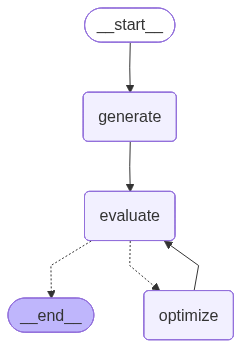

In [36]:
workflow

In [ ]:
initial_state = {
    'topic' : 'Indian Railways',
    'iteration' : 1,
    'max_iteration' : 5
}

# final_state = workflow.invoke(initial_state)

print(final_state)

{'topic': 'Indian Railways', 'tweet': 'Just saw an Indian Railways announcement that said "Punctuality is our priority." Pretty sure my chaiwala makes more timely arrivals. 🚂💨 #IndianRailways #TrainLife #Priorities', 'evaluation': 'Needs improvement', 'feedback': "The tweet attempts humor by contrasting the official statement of Indian Railways with a personal observation about punctuality. However, the comparison to a 'chaiwala' making more timely arrivals is a tired trope and lacks originality. The humor is mild and unlikely to elicit a strong reaction. While it adheres to the character limit and format, the predictability of the joke and the lack of a strong punchline limit its virality potential. It needs a more unique angle or a sharper observational twist to be effective.", 'iteration': 1, 'max_iteration': 5}
